# Clase 1 — Introducción a los Transformers

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Google Colab"/></a>

> Para usarlo en Google Colab: sube este notebook a Colab o guárdalo en Drive y ábrelo desde `Archivo > Abrir notebook`.

Los **Transformers** son la arquitectura detrás de casi todo lo que hoy llamamos IA moderna: modelos de lenguaje (GPT, Claude, Llama), de visión (ViT), y multimodales (CLIP). Esta primera clase construye la arquitectura **desde su origen**: el problema de traducción, el mecanismo de **atención**, y cómo la **self-attention** hizo posible eliminar la recurrencia.

**Objetivos.** Al terminar esta clase deberías poder:
1. Representar datos (texto, imágenes) como **vectores** y entender qué es una **proyección lineal**.
2. Explicar el esquema **seq2seq** con RNN y su **cuello de botella**.
3. Describir el mecanismo de **atención** (scores → softmax → suma ponderada) y por qué aporta *interpretabilidad*.
4. Derivar la **self-attention** ($Q$, $K$, $V$, *scaled dot-product*) e implementarla desde cero.
5. Ensamblar un **bloque Transformer** (multi-head + MLP + norm + residual), con **positional encoding** y **máscara causal**.

**Formato (≈ 3 horas).** Esta clase combina **teoría** (conceptos + demos) y **práctica** (código que construyes tú). Los bloques 🧪 son prácticos.

| Bloque | Tema | ~min |
|---|---|---|
| 0 | Del dato al vector: proyecciones | 20 |
| 1 | Traducción, seq2seq y el cuello de botella | 25 |
| 2 | Atención neuronal | 30 |
| — | *Descanso* | 10 |
| 3 | Self-attention (la base del Transformer) | 35 |
| 4 | Multi-head, el bloque Transformer y positional encoding | 30 |
| 5 | 🧪 Práctica: un bloque Transformer desde cero | 30 |

## Bloque 0 · Del dato al vector

Primero, el *setup*. Ejecuta estas dos celdas (la segunda instala nuestra librería de visualizaciones `dlviz`).

In [ ]:
# Setup
import numpy as np, matplotlib.pyplot as plt
#Pytorch
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.11.0+cu128 | device: cuda


In [ ]:
!pip install -q dlviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.2 MB/s eta 0:00:00


Una red neuronal es un **modelo numérico**: todos sus datos tienen que ser **números**. El primer paso, siempre, es convertir el dato (una imagen, una frase) en un **vector** $X \in \mathbb{R}^m$. [Ver infografía](https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/infografias/M1/01_Representación_Vectorial_en_IA.png)

- **Imágenes:** se recorren como una secuencia de trozos (filas, o *parches* — lo veremos en la Clase 3).
- **Texto:** cada palabra se asocia a un vector aprendido, su **embedding**. Palabras con significado parecido quedan **cerca** en el espacio.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_00_tipos_rnn.png" width="720">

<sub>Los datos con estructura secuencial (texto, audio, series) se procesan como una secuencia de vectores.</sub>

In [ ]:
# Demo: embeddings — palabras parecidas quedan cerca en el espacio
# (vectores de juguete, dim 7, inspirados en la lámina 'Los datos - texto')
palabras = {
 "cat":   [ 0.6, 0.9, 0.1, 0.4,-0.7,-0.3,-0.2],
 "kitten":[ 0.5, 0.8,-0.1, 0.2,-0.6,-0.5,-0.1],
 "dog":   [ 0.7,-0.1, 0.4, 0.3,-0.4,-0.1,-0.3],
 "houses":[-0.8,-0.4,-0.5, 0.1,-0.9, 0.3, 0.8],
}
E = {k: torch.tensor(v) for k,v in palabras.items()}
def coseno(a,b): return torch.dot(a,b)/(a.norm()*b.norm())
print("Similitud coseno:")
print(f"  cat  ↔ kitten : {coseno(E['cat'],  E['kitten']):.2f}   (muy parecidas)")
print(f"  cat  ↔ dog    : {coseno(E['cat'],  E['dog']):.2f}   (algo parecidas)")
print(f"  cat  ↔ houses : {coseno(E['cat'],  E['houses']):.2f}   (muy distintas)")

Similitud coseno:
  cat  ↔ kitten : 0.96   (muy parecidas)
  cat  ↔ dog    : 0.61   (algo parecidas)
  cat  ↔ houses : -0.21   (muy distintas)


### Proyecciones lineales

La operación fundamental de una red es la **proyección lineal**: convertir un vector $X$ de dimensión $m$ en otro vector $X'$ de dimensión $q$, mediante una **matriz** $P_{m\times q}$:

$$ X' = X \cdot P_{m,q} $$

- Si $m < q$: *up-dimension* (subir de dimensión).
- Si $m > q$: *down-dimension* (bajar de dimensión).

Toda la atención —el corazón del Transformer— se construye a partir de **tres** de estas proyecciones. Guarda esta idea.

In [ ]:
# Demo: una proyección lineal como multiplicación por una matriz de parámetros
X = torch.tensor([[1.5, 2.5]])          # un dato en R^2  (fila)
P = torch.tensor([[0.5, 0.6, -0.8],
                  [0.6,-1.2,  0.2]])    # matriz 2x3  (parámetros)
Xp = X @ P                              # -> R^3  (up-dimension: 2 -> 3)
print("X  :", X.tolist(), " dim", X.shape[-1])
print("X' :", Xp.round(decimals=2).tolist(), " dim", Xp.shape[-1])
print("En una red, P se APRENDE. nn.Linear(2,3) hace exactamente esto (+ bias).")

X  : [[1.5, 2.5]]  dim 2
X' : [[2.25, -2.0999999046325684, -0.699999988079071]]  dim 3
En una red, P se APRENDE. nn.Linear(2,3) hace exactamente esto (+ bias).


## Bloque 1 · Traducción, seq2seq y el cuello de botella

El problema histórico que dio origen a la atención es la **traducción automática** (*machine translation*): dada una frase en un idioma (*source*), producir la frase equivalente en otro (*target*).

$$ \text{"El bebé está llorando"} \;\longrightarrow\; \text{"The baby is crying"} $$

La solución con redes neuronales es el modelo **seq2seq** (*sequence-to-sequence*): dos RNN encadenadas. [Ver infografía](https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/infografias/M3/01_RNN.png)</sub>
- El **encoder** (una RNN) lee la frase de origen y produce un **encoding**: un vector que resume *toda* la secuencia.
- El **decoder** (otra RNN) genera la traducción palabra por palabra, condicionada en ese encoding.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_03_seq2seq.png" width="760">

<sub>seq2seq: el encoder comprime la frase de origen en un vector; el decoder genera la traducción a partir de él.</sub>

In [ ]:
from dlviz import seq2seq_interactiva
seq2seq_interactiva()

El decoder es un **modelo de lenguaje condicional**: predice una palabra a la vez, y cada predicción usa las anteriores más el encoding de origen. Formalmente descompone la probabilidad de la frase completa:

$$ P(y\mid x) = \prod_{t=1}^{T} P\!\left(y_t \mid y_1,\dots,y_{t-1},\, x\right) $$

**El problema (cuello de botella):** el encoder debe comprimir *toda* la información de la frase de origen en un **único** vector de tamaño fijo. Para frases largas, ese vector se convierte en un embudo que pierde información.

> **Nota sobre inferencia.** Al generar, tomar siempre la palabra más probable (*greedy decoding*) es miope: una decisión temprana no se puede deshacer. **Beam search** mantiene las $k$ secuencias más probables en cada paso (según la suma de log-probabilidades) y elige la mejor al final. Es un detalle importante de los generadores, y volveremos a él en la Clase 2.

## Bloque 2 · Atención neuronal

**Idea:** ¿por qué comprimir todo en un solo vector? En vez de eso, dejemos que el decoder **mire todos los estados intermedios** del encoder y decida, *en cada paso*, en cuáles concentrarse. Eso es la **atención**.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_04_atencion.png" width="760">

<sub>Atención: en cada paso el decoder calcula un score con cada estado del encoder, los normaliza con softmax, y produce una suma ponderada (el contexto).</sub>

La mecánica, paso a paso. Sean $h_1,\dots,h_N$ los estados ocultos del encoder y $s_t$ el estado del decoder en el paso $t$:

1. **Scores** — similitud (producto interno) entre $s_t$ y cada $h_i$:
$$ e_t = [\,s_t^\top h_1,\; s_t^\top h_2,\;\dots,\; s_t^\top h_N\,] $$
2. **Softmax** — convertir los scores en una distribución de probabilidad (pesos que suman 1):
$$ \alpha_t = \text{softmax}(e_t) $$
3. **Contexto** — suma ponderada de los estados del encoder:
$$ a_t = \sum_{i=1}^{N} \alpha_t^i\, h_i $$

El contexto $a_t$ se combina con $s_t$ para predecir la palabra. **Variantes** de atención cambian el paso 1 (producto interno, multiplicativa $s_t^\top W h_i$, aditiva).

In [ ]:
# Demo: atención como suma ponderada (el decoder mira 4 estados del encoder)
torch.manual_seed(1)
estados_encoder = torch.randn(4, 6)          # 4 tokens de origen, dim 6
estado_decoder  = torch.randn(6)             # estado actual del decoder
scores  = estados_encoder @ estado_decoder   # (1) similitud con cada estado
pesos   = torch.softmax(scores, dim=0)        # (2) softmax -> distribución
contexto = pesos @ estados_encoder            # (3) suma ponderada
print("pesos de atención (suman 1):", pesos.round(decimals=2).tolist())
print("-> el decoder se concentra en el token", pesos.argmax().item())

pesos de atención (suman 1): [0.0, 0.029999999329447746, 0.9700000286102295, 0.0]
-> el decoder se concentra en el token 2


**Bono: interpretabilidad.** Los pesos de atención $\alpha$ son *legibles*. Al traducir, revelan la **alineación** entre palabras de origen y palabras generadas — algo que las RNN puras no ofrecían.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_05_alignment.png" width="520">

<sub>Los pesos de atención muestran qué palabra de origen se alinea con cada palabra traducida.</sub>

In [ ]:
from dlviz import nmt_atencion_interactiva
nmt_atencion_interactiva()

## Bloque 3 · Self-attention (la base del Transformer)

Hasta aquí la atención conecta *dos* secuencias (decoder → encoder). La gran idea de 2017 (*Attention is all you need*) fue:

> ¿Y si aplicamos atención de una secuencia **sobre sí misma**?

Cada vector de la colección aplica atención sobre **todos** los vectores de la misma colección y produce un vector nuevo que mezcla información de sus relaciones. Con esto, **ya no necesitamos recurrencia**: todo se calcula en paralelo.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_06_selfattention.png" width="720">

<sub>Self-attention: cada token atiende a todos los tokens de la secuencia (incluido él mismo) y se recombina.</sub>

Si $X$ es la matriz de la secuencia (cada fila un embedding, tamaño $\text{seq}\times \text{dim}$), la versión más simple sería $\text{softmax}(XX^\top)\,X$. Pero eso no tiene parámetros que aprender. La solución del Transformer: **proyectar** $X$ en tres roles distintos —*query*, *key*, *value*— con tres matrices aprendibles $W_Q, W_K, W_V$:

$$ Q = XW_Q,\quad K = XW_K,\quad V = XW_V $$

$$ \boxed{\;\text{Attention}(Q,K,V) = \text{softmax}\!\left(\dfrac{QK^\top}{\sqrt{d_k}}\right)V\;} $$

- $QK^\top$ mide la **similitud** entre cada par de tokens (matriz $\text{seq}\times\text{seq}$).
- Dividir por $\sqrt{d_k}$ (*scaled*) evita que los scores crezcan demasiado y saturen el softmax.
- El resultado es un **promedio ponderado de los values**.

Recuerda el Bloque 0: son **tres proyecciones lineales**. Eso es todo.

In [ ]:
from dlviz import self_attention_interactiva
self_attention_interactiva()

A continuación lo implementamos **desde cero** y visualizamos la matriz de atención.

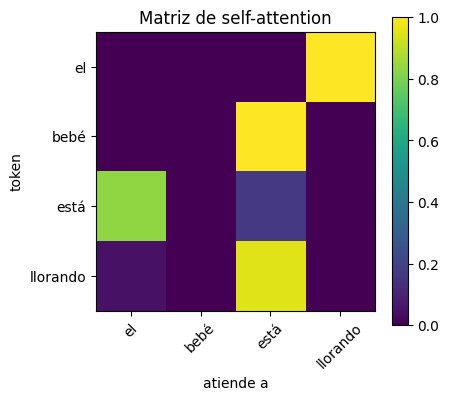

Cada fila suma 1: [1.0, 1.0, 1.0, 1.0]
Salida: (4, 16) -> mismo nº de tokens, cada uno recombinado


In [ ]:
# Demo: self-attention desde cero, visualizando la matriz de atención
torch.manual_seed(0)
tokens = ["el", "bebé", "está", "llorando"]
n, d, dk = len(tokens), 16, 16
X = torch.randn(n, d)                              # secuencia (n tokens, dim d)
Wq, Wk, Wv = (torch.randn(d, dk) for _ in range(3))# 3 proyecciones aprendibles
Q, K, V = X @ Wq, X @ Wk, X @ Wv
A = torch.softmax(Q @ K.T / dk**0.5, dim=-1)       # matriz de atención (n x n)
out = A @ V                                        # salida: promedio ponderado de V

plt.figure(figsize=(4.5, 4))
plt.imshow(A.detach(), cmap="viridis")
plt.xticks(range(n), tokens, rotation=45); plt.yticks(range(n), tokens)
plt.xlabel("atiende a"); plt.ylabel("token")
plt.title("Matriz de self-attention"); plt.colorbar(); plt.show()
print("Cada fila suma 1:", A.sum(-1).round(decimals=2).tolist())
print("Salida:", tuple(out.shape), "-> mismo nº de tokens, cada uno recombinado")

## Bloque 4 · Multi-head, el bloque Transformer y positional encoding

### Multi-head attention
Una sola atención captura *un* tipo de relación. Para enriquecerla, se usan varias **cabezas** en paralelo, cada una con sus propias $W_Q,W_K,W_V$. Cada cabeza puede especializarse (una en sintaxis, otra en correferencia, etc.); sus salidas se **concatenan** y una capa lineal final devuelve la dimensión original.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_07_multihead.png" width="700">

<sub>Multi-head: varias atenciones en paralelo, cada una con sus proyecciones; se concatenan y se proyectan de vuelta.</sub>

In [ ]:
from dlviz import multi_head_interactiva
multi_head_interactiva()

### El bloque Transformer
El **Transformer** apila $N$ bloques. Cada bloque del **encoder** es:

`multi-head self-attention` → `Add & Norm` → `MLP (2 capas, ReLU)` → `Add & Norm`

Las **conexiones residuales** (*Add*) y la **normalización** (*Norm*) estabilizan el entrenamiento de redes profundas. El **decoder** añade una self-attention **enmascarada** (causal) sobre el target y una atención cruzada hacia la salida del encoder.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_08_transformer.png" width="400">

<sub>Arquitectura Transformer: bloques de encoder (izq.) y decoder (der.), repetidos N veces.</sub>

### Positional encoding
La self-attention es **permutación-invariante**: no sabe el orden de los tokens. Se le inyecta el orden **sumando** al embedding un *positional encoding* — en la propuesta original, funciones senoidales de distinta frecuencia según la posición y la dimensión:

$$ PE_{(pos,\,2i)} = \sin\!\big(pos/10000^{\,2i/d}\big), \qquad PE_{(pos,\,2i+1)} = \cos\!\big(pos/10000^{\,2i/d}\big) $$

In [ ]:
from dlviz import positional_encoding_interactiva
positional_encoding_interactiva()

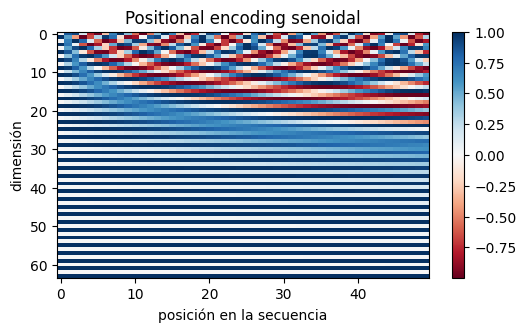

In [ ]:
# Demo: positional encoding senoidal
def positional_encoding(seq_len, d):
    pos = torch.arange(seq_len).unsqueeze(1)
    i   = torch.arange(d).unsqueeze(0)
    ang = pos / (10000 ** (2*(i//2)/d))
    pe  = torch.zeros(seq_len, d)
    pe[:, 0::2] = torch.sin(ang[:, 0::2])
    pe[:, 1::2] = torch.cos(ang[:, 1::2])
    return pe

PE = positional_encoding(seq_len=50, d=64)
plt.figure(figsize=(6,3.2))
plt.imshow(PE.T, cmap="RdBu", aspect="auto")
plt.xlabel("posición en la secuencia"); plt.ylabel("dimensión")
plt.title("Positional encoding senoidal"); plt.colorbar(); plt.show()

### Máscara causal
En el decoder, al predecir el token $t$ **no se puede mirar el futuro**. Se implementa fácilmente en la propia atención: se ponen a $-\infty$ los scores de las posiciones futuras, y el softmax los convierte en 0.

<img src="https://raw.githubusercontent.com/ivansipiran/Deep-Learning/main/img/m3_09_causal_mask.png" width="460">

<sub>Máscara causal: cada posición solo atiende a sí misma y a las anteriores.</sub>

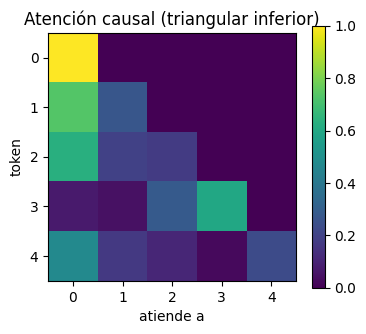

La posición 0 solo se ve a sí misma; la última ve a todas las anteriores.


In [ ]:
# Demo: máscara causal sobre una matriz de atención
n = 5
scores = torch.randn(n, n)
mask = torch.triu(torch.ones(n, n), diagonal=1).bool()  # True = futuro (prohibido)
scores_masked = scores.masked_fill(mask, float("-inf"))
A = torch.softmax(scores_masked, dim=-1)
plt.figure(figsize=(4,3.4))
plt.imshow(A.detach(), cmap="viridis")
plt.title("Atención causal (triangular inferior)")
plt.xlabel("atiende a"); plt.ylabel("token"); plt.colorbar(); plt.show()
print("La posición 0 solo se ve a sí misma; la última ve a todas las anteriores.")

## Bloque 5 · 🧪 Práctica: un bloque Transformer desde cero

Ahora **construyes tú**. Vamos a ensamblar una self-attention multi-head y un bloque Transformer completo, y luego lo compararemos con la versión de PyTorch (`nn.TransformerEncoderLayer`).

In [ ]:
# 1) Multi-head self-attention en una sola clase
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dk = n_heads, d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)
    def forward(self, x, mask=None):
        B, T, D = x.shape
        # proyectar y separar en cabezas: (B, h, T, dk)
        q = self.Wq(x).view(B, T, self.h, self.dk).transpose(1, 2)
        k = self.Wk(x).view(B, T, self.h, self.dk).transpose(1, 2)
        v = self.Wv(x).view(B, T, self.h, self.dk).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / self.dk**0.5      # (B, h, T, T)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        A = scores.softmax(-1)
        out = (A @ v).transpose(1, 2).contiguous().view(B, T, D)
        return self.Wo(out), A

mha = MultiHeadSelfAttention(d_model=32, n_heads=4)
x = torch.randn(2, 6, 32)               # batch=2, 6 tokens, dim 32
y, A = mha(x)
print("entrada:", tuple(x.shape), "-> salida:", tuple(y.shape))
print("matriz de atención por cabeza:", tuple(A.shape), "(B, heads, T, T)")

entrada: (2, 6, 32) -> salida: (2, 6, 32)
matriz de atención por cabeza: (2, 4, 6, 6) (B, heads, T, T)


In [ ]:
# 2) Bloque Transformer: atención + MLP, con residual y LayerNorm
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4*d_model
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),
                                 nn.Linear(d_ff, d_model))
    def forward(self, x, mask=None):
        a, A = self.attn(self.norm1(x), mask)      # pre-norm
        x = x + a                                   # residual 1
        x = x + self.mlp(self.norm2(x))             # residual 2
        return x, A

blk = TransformerBlock(d_model=32, n_heads=4)
y, A = blk(x)
n_params = sum(p.numel() for p in blk.parameters())
print("salida del bloque:", tuple(y.shape), "| parámetros:", n_params)

salida del bloque: (2, 6, 32) | parámetros: 12704


### 🧩 Ejercicio 1 — Máscara causal
La clase `MultiHeadSelfAttention` acepta un argumento `mask`. Construye una **máscara causal** de tamaño `T×T` (broadcast a `(1,1,T,T)`) y pásala al bloque. Verifica, imprimiendo una fila de la matriz de atención `A`, que la posición 0 solo atiende a sí misma.

In [ ]:
# @title Solución
T = x.shape[1]
causal = torch.triu(torch.ones(T, T), diagonal=1).bool().view(1, 1, T, T)
y, A = blk(x, mask=causal)
print("fila 0 de atención (cabeza 0, ejemplo 0):", A[0,0,0].round(decimals=2).tolist())
print("-> solo la posición 0 tiene peso; el resto es 0 (no mira el futuro).")

fila 0 de atención (cabeza 0, ejemplo 0): [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
-> solo la posición 0 tiene peso; el resto es 0 (no mira el futuro).


### Lo mismo, con PyTorch
En la práctica no reimplementas la atención: usas `nn.TransformerEncoderLayer`, que hace exactamente lo que construimos (multi-head + MLP + norm + residual).

In [ ]:
capa = nn.TransformerEncoderLayer(d_model=32, nhead=4, dim_feedforward=128,
                                  batch_first=True)
encoder = nn.TransformerEncoder(capa, num_layers=3)
y = encoder(x)
print("nn.TransformerEncoder ->", tuple(y.shape),
      "| params:", sum(p.numel() for p in encoder.parameters()))

nn.TransformerEncoder -> (2, 6, 32) | params: 38112


### 🧩 Ejercicio 2 — Reto
Con `nn.TransformerEncoder`, arma un **mini-clasificador de secuencias**: añade un token `[CLS]` al inicio (un embedding aprendible), pasa la secuencia por el encoder, y usa la salida del `[CLS]` con un `nn.Linear` para clasificar. Este es *exactamente* el patrón de **BERT** (Clase 2) y de **ViT** (Clase 3). Pruébalo con datos sintéticos.

In [ ]:
# @title Solución (esqueleto)
class ClasificadorCLS(nn.Module):
    def __init__(self, d_model=32, n_heads=4, n_layers=2, n_clases=3):
        super().__init__()
        self.cls = nn.Parameter(torch.randn(1, 1, d_model))     # token [CLS]
        capa = nn.TransformerEncoderLayer(d_model, n_heads, 4*d_model, batch_first=True)
        self.enc = nn.TransformerEncoder(capa, n_layers)
        self.head = nn.Linear(d_model, n_clases)
    def forward(self, x):                                        # x: (B, T, d)
        B = x.shape[0]
        cls = self.cls.expand(B, -1, -1)
        h = self.enc(torch.cat([cls, x], dim=1))                # (B, T+1, d)
        return self.head(h[:, 0])                                # salida del [CLS]

modelo = ClasificadorCLS()
logits = modelo(torch.randn(8, 6, 32))
print("logits:", tuple(logits.shape), "-> (batch, nº de clases)")

## Cierre

Recorrimos el nacimiento del Transformer: del **cuello de botella** del seq2seq, a la **atención** que lo resuelve, a la **self-attention** que elimina la recurrencia, hasta el **bloque Transformer** completo con multi-head, positional encoding y máscara causal — que implementaste desde cero.

El mismo bloque, con pequeñas variaciones, es la base de todo lo que viene:
- **Clase 2 — NLP:** apilar decoders para construir **LLMs** (GPT, Claude), muestreo, preentrenamiento y fine-tuning.
- **Clase 3 — Visión:** trocear una imagen en parches y alimentar el *mismo* Transformer → **ViT**.
- **Clase 4 — Multimodal:** unir visión y lenguaje (**CLIP**) y el aprendizaje **auto-supervisado**.

> **Para reflexionar.** El patrón `[CLS] + Transformer + cabeza lineal` del Ejercicio 2 reaparece en BERT y en ViT. Un mismo mecanismo —la atención— sirve para texto, imágenes y sonido. Esa universalidad es la razón de su impacto.